# Batch Normalization

Paper Link: https://arxiv.org/abs/1502.03167

- Internal Covariate Shift: a phenomena where the "distribution of each layer’s inputs changes during training" and this requires lower learning rates to remedy
    - All the weights get updated at once in a model. So just when Layer 2 adjusted its weights to the distribution of the inputs it got from Layer 1, that distribution also changed.
 
- Increasing batch sizes offers at least 2 benefits
    - First, the gradient that you obtain is a better estimate of the entire data set (more samples)
    - Second, the computation is more efficient due to parallelism

- Frequently, there is a problem of an output from a layer making it such that it enters a region where the gradient is near 0. This is only amplified in deep networks, partly due to the internal covariate shift.
- In the paper they call linearly transforming input to have zero means and unit variances "whitening"
    - This is not just a regular normalization, in this case the features will also be made to be independent of each other which is computationally very expensive.
- They describe the error with trying to subtract the mean from the layer inputs after each training step.
    - I won't explain it in detail (mainly because I didn't fully grasp it), but the problem seems to be that when gradient descent updates the values of the parameters, the mean changes in response to the value difference. And therefore the changes kind of cancel out and training stalls
- They pointed out that normalizing each input of a layer changes what the layer can represent
- Normalizing the input is just subtracting the mean and dividing by standard deviation.
    - Take for instance a sigmoid function. Near 0 it actually looks fairly linear. So when we normalize the inputs to the sigmoid function we get a more-or-less linear transformation which makes the network a linear function itself
    -  To remedy this they give the model the capability to kind of untransform the data via a pair of parameters $\gamma, \beta$ in the equation $y = \gamma \widehat{x} + \beta$
        - If you set $\gamma = \sqrt{Var[x]}$ and $\beta = \mathbb{E}[x]$ then you return the original value before the normalization.
- When using batches, we use the statistics from those mini-batches to produce an estimate of the mean and the variance.
    - Relies on the estimates to be good enough

### The Algorithm
- Input: Values of $x$ in the mini-batch $B$
- Parameters to be learned $\gamma, \beta$ (the fact that we have $B$ for batch and $\beta$ for a parameter is pretty criminal imo)
- Steps:
    - We get the mean of the mini-batch $\mu_B = 1/m \sum x_i$
    - We get the variance $\sigma^2_B = 1/m \sum (x_i-\mu_B)^2$
    - Normalize the input $\widehat{x_i}=\frac{x_i-\mu_B}{\sqrt{\sigma^2_B + \epsilon}}$
    - Scale and shift using the learned parameters $y_i = \gamma \widehat{x_i}+\beta$

The algorithm above works great for training. But for inference we don't want to have the randomness that sample statistics from mini-batches provide. So we need to have the population stats. 

We could just get the stats from the full training set, but this is not ideal for several ideas. One of them is that if you're working with a large dataset this is computationally not that cheap. It's also tough to do this with a validation set since you are technically leaking information from the test set into training. 

### Code
WARNING: This code is awful. You might hurt your retinas just reading this. Instead of attempting to describe what is going on here, I will write the lessons that I learned along the way. 

- A batching based technique does not work well with a scalar autograd engine. Who would've thought? Everything is a gross looking for loop, it was impossible to keep track of what was a Node class and what wasn't.
    - From the future: I should've used numpy's dtype, this would've saved me from the war crimes that I committed 
- Even after reading the paper and thinking that I understood mostly everything, I realized that I didn't decipher as much as I thought. Shows how important some sort of active recall is. Especially with immediate feedback.
- I simplified the notation when taking notes on all of this because I was too lazy to write things out in LaTeX. This was one of the reasons I misunderstood a lot things. For one I thought that the gamma and beta parameters were actually scalars, I didn't realize that they were there for every single layer.
- We run BatchNorm on linear activations, not on inputs of every layer. Though, as I researched this more it seems like this is a topic of debate. To me, if our goal is to make sure that the input of every layer is on the same scale each time, then applying it after activation function is more reasonable.
    - Gemini doesn't really give me a clear answer either. Pre-activation normalization is better for gradient flow in something like sigmoid or tanh functions. Post-activation will give a cleaner input to the next layer.
- Had to use AI to help me with debugging the code that I wrote because it got so out of hand.
- XOR was actually a pretty bad problem to test this on. The whole thing with BN is that it is good for deeper networks that are more prone to ICS. My dataset is tiny so estimating means and variances just add ton of noise that the model did not need. 

In [ ]:
import numpy as np
from matplotlib import pyplot as plt 
from sklearn.model_selection import train_test_split
rng = np.random.default_rng(seed=42)


In [ ]:
class Node:
    def __init__(self, val, parents=[], operation=""):
        self.val = val
        self.parents = parents
        self.gradient = 0.0
        self.operation = operation

    def __add__(self, other_node):
        if type(other_node) != Node:
            other_node = Node(other_node)
        new_node = Node(self.val + other_node.val, parents=[self,other_node],operation="+")
        return new_node

    def __mul__(self, other_node):
        if type(other_node) != Node:
            other_node = Node(other_node)
        new_node = Node(self.val * other_node.val, parents=[self,other_node],operation="*")
        return new_node

    def log(self):
        return Node(np.log(self.val + 1e-5),parents=[self], operation="log")

    def relu(self):
        return Node(max(0,self.val),parents=[self], operation="relu")

    def sigmoid(self):
        new_val = 1/(1+np.exp(-self.val))
        return Node(new_val,parents=[self], operation="sigmoid")

    def _backprop(self):
        if not self.parents:
            pass
        elif self.operation == "+":
            self.parents[0].gradient += self.gradient
            self.parents[1].gradient += self.gradient
        elif self.operation == "*":
            self.parents[0].gradient += self.gradient * self.parents[1].val
            self.parents[1].gradient += self.gradient * self.parents[0].val
        elif self.operation == "relu":
            self.parents[0].gradient += 0 if self.val <= 0 else self.gradient
        elif self.operation == "sigmoid":
            sigmoid_dx = self.val * (1-self.val)
            self.parents[0].gradient += self.gradient * sigmoid_dx
        elif self.operation == "log":
            self.parents[0].gradient += self.gradient / (self.parents[0].val + 1e-5)
    
    # This code was AI generated, I didn't really feel like implementing a topological sort
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for p in v.parents:
                    build_topo(p)
                topo.append(v)
        build_topo(self)
    
        self.gradient = 1.0
        for node in reversed(topo):
            node._backprop() 
            


In [111]:
class Neuron:
    def __init__(self, in_dim, activation = "relu"):
        self.weight = [Node(rng.random()) for _ in range(in_dim)]
        self.bias = Node(rng.random())
        self.activation = activation

    def _lin_sum(self, x):
        s = Node(0)
        for i in range(len(x)):
            s += self.weight[i]* x[i] 
        return s + self.bias

    def _activate(self,x):
        if self.activation == "relu":
            return x.relu()
        elif self.activation == "sigmoid":
            return x.sigmoid()

    def forward(self, z, mean, var, gamma, beta):
        z_norm = (z + mean * Node(-1)) * Node(1/(np.sqrt(var.val + 1e-10)))
        z_transform = gamma * z_norm + beta
        a = self._activate(z_transform)
        return a
            

class Layer:
    def __init__(self, in_dim, out_dim, activation="relu"):
        self.Neurons = [Neuron(in_dim, activation=activation) for _ in range(out_dim)]
        self.running_mean = [0] * out_dim
        self.running_var = [1] * out_dim
        self.momentum = 0.99

    def forward(self,x_batch, gamma, beta, inference):
        z_list = []
        for x in x_batch:
            neuron_z = [neuron._lin_sum(x) for neuron in self.Neurons]
            z_list.append(neuron_z)

        sum_z = [Node(0) for _ in range(len(self.Neurons))] 
        for neuron_z in z_list:
           for i in range(len(neuron_z)):
               sum_z[i] += neuron_z[i]
        batch_means = [z * Node(1/len(x_batch)) for z in sum_z]
        
        batch_vars = [Node(0) for _ in range(len(self.Neurons))]
        for neuron_z_row in z_list:
            for i in range(len(neuron_z_row)):
                diff = neuron_z_row[i] + (batch_means[i] * -1)
                batch_vars[i] += diff * diff
        batch_vars = [v_i * Node(1/len(x_batch)) for v_i in batch_vars]

        self.running_mean = [self.momentum * self.running_mean[i] + (1-self.momentum) * batch_means[i].val for i in range(len(self.Neurons))]
        self.running_var = [self.momentum * self.running_var[i] + (1-self.momentum) * batch_vars[i].val for i in range(len(self.Neurons))]

        output_batch = []
        for b in range(len(x_batch)):
            output_row = []
            if not inference:
                for i in range(len(self.Neurons)):
                    a = (self.Neurons[i].forward(z_list[b][i],batch_means[i], batch_vars[i], gamma[i], beta[i]))
                    output_row.append(a)
            else: 
                for i in range(len(self.Neurons)):
                    a = (self.Neurons[i].forward(z_list[b][i],Node(self.running_mean[i]), Node(self.running_var[i]), gamma[i], beta[i]))
                    output_row.append(a)
            output_batch.append(output_row)
            
        return output_batch


class BatchNormNN:
    def __init__(self, neurons_per_layer, activations, input_dim = 2, batch_size = 32):
        self.loss_history = []
        self.Layers = []
        self.gamma = [[Node(rng.normal() * 2) for _ in range(n)] for n in neurons_per_layer]
        self.beta = [[Node(0.0) for _ in range(n)] for n in neurons_per_layer]
        self.m = batch_size
        in_d = input_dim
        for i in range(len(neurons_per_layer)):
            out_d = neurons_per_layer[i] 
            self.Layers.append(Layer(in_d,out_d, activation=activations[i]))
            in_d = neurons_per_layer[i]
    
    def forward(self, x, inference = False):
        for i in range(len(self.Layers)):
            x = self.Layers[i].forward(x, self.gamma[i], self.beta[i], inference = inference)
        return x

    def calculate_loss(self, y_pred, y_true):
        if not isinstance(y_true, Node):
            y_true = Node(y_true)
        left_side = y_true * y_pred.log()
        temp = Node(1) + y_pred * Node(-1)
        right_side = (Node(1) + y_true * Node(-1)) * temp.log()
        total = Node(-1) * (left_side+right_side)
        return total

    def get_params(self):
        output = []
        for i in range(len(self.gamma)):
            output += self.gamma[i]
            output += self.beta[i]
        
        for layer in self.Layers:
            for neuron in layer.Neurons:
                for weight in neuron.weight:
                    output.append(weight)
                output.append(neuron.bias)

        return output

    def train(self, X, Y, epochs = 10, a=0.01): 
        for _ in range(epochs):
            indices = np.arange(len(X))
            rng.shuffle(indices)
            for i in range(0, len(indices), self.m):
                batch_idx = indices[i: i+self.m]

                x_batch = [X[idx] for idx in batch_idx]
                y_batch = [Y[idx] for idx in batch_idx]
                
                loss = Node(0)

                y_pred = self.forward(x_batch)

                for i in range(len(y_pred)):
                    loss += self.calculate_loss(y_pred[i][0],y_batch[i])

                loss *= Node(1/len(y_pred))
                self.loss_history.append(loss.val)
                
                loss.gradient = 1
                loss.backward()

                params = self.get_params()
                for param in params:
                    param.val -= a * param.gradient
                    param.gradient = 0        # don't forget to zero out the gradients


Notes to self
---
Even after reading the paper, I didn't understand as much as I thought.

We normalize the linear sum, not anything else.
The parameters are for each layer and not just the same thorughtout 
Same with the running mean and variances
Designing a scalar autograd to work with a Batch based algorithm is the dumbest shit ever and this was a terrible idea.

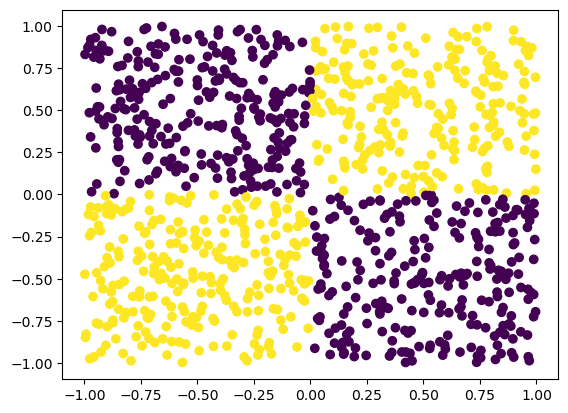

In [97]:
N = 1000
X = rng.uniform(-1,1,(N,2))
Y = np.zeros((N,1))
Y[X[:,0] * X[:,1] > 0] = 1

plt.scatter(X[:,0],X[:,1], c=Y)

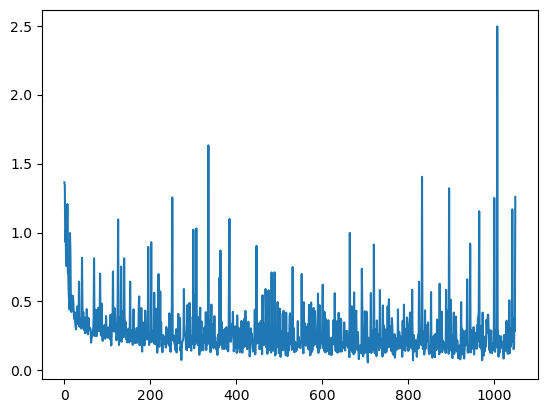

In [112]:
X_train, X_test, Y_train, Y_test = train_test_split(X,Y,test_size = 0.8)

NN = BatchNormNN([8,4,1], activations = ["relu","relu","sigmoid"])
NN.train(X_train, Y_train, a=0.1, epochs = 150)

plt.plot(NN.loss_history)

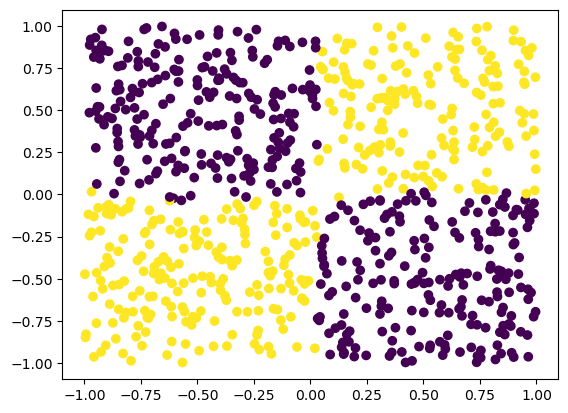

In [113]:
test_outputs = NN.forward(list(X_test), inference=True)
predictions = [np.round(out[0].val) for out in test_outputs]

plt.scatter(X_test[:,0], X_test[:,1], c=predictions)